Используются данные - https://www.kaggle.com/datasets/mar1mba/russian-sentiment-dataset

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn

from natasha import (
    Segmenter,
    MorphVocab,
    NewsEmbedding,
    NewsMorphTagger,
    NewsSyntaxParser,
    Doc
)
from pymorphy3 import MorphAnalyzer

from collections import Counter
from typing import Tuple, Optional, List

In [2]:
df = pd.read_csv("sentiment_dataset.csv")

In [3]:
df

,text,label,src
0,"Пальто красивое, но пришло с дырой в молнии. П...",0,rureviews
1,"Очень долго шел заказ,ждала к новому году,приш...",0,rureviews
2,"Могу сказать одно, брюки нормальные, НО они бы...",0,rureviews
3,"Доставка быстрая, меньше месяца. Заказывали ра...",0,rureviews
4,Мне не очень понравилось это платье. Размер ...,0,rureviews
...,...,...,...
290453,Как всегда вкусный и свежий.,1,perekrestok
290454,Обалденный!,1,perekrestok
290455,"Достоинства:\nВкусно, лучшая паста\n\nНедостат...",1,perekrestok
290456,"Достоинства:\nУвлажняет очень хорошо, и кожа к...",1,perekrestok


In [4]:
df["text"] = df["text"].str.replace("\r", " ", regex=False)
df["text"] = df["text"].str.replace("\n", " ", regex=False)
df["text"] = df["text"].str.replace("\r\n", " ", regex=False)

text = list(df["text"].values)[:50001]

In [5]:
text

['Пальто красивое, но пришло с дырой в молнии. Просила выслать такую же, но продавец настаивал на открытии спора.  Али экспресс предложил либо вернуть товар либо компенсацию 659р.При возврате непонятно, кто оплачивает доставку, к тому же я хотела носить пальто. В ателье выяснилось, что вся молния обрезана, а сверху защита тонкой планкой.',
 'Очень долго шел заказ,ждала к новому году,пришел, когда уже не нужен,разочарована.',
 'Могу сказать одно, брюки нормальные, НО они были порваны, и малы, заказывала второй раз, в этот раз заказала на размер больше, но размер пришёл меньше, деньги вернули за повреждение товара, за это огромное спасибо продавцу, а так брюки дошли за   14-15 дней... но порваны, очень жаль ',
 'Доставка быстрая, меньше месяца. Заказывали размер L а пришёл s.еачество среднее, края не обработаны, но за такие деньги сойдёт ',
 'Мне не очень  понравилось это платье. Размер  L подошёл, зелёного цвета, но смотрится не очень. Пришло быстро.  Спасибо.',
 'внешне качество хороше

In [6]:
segmenter = Segmenter() 
embedding = NewsEmbedding() 
morph_tagger = NewsMorphTagger(embedding) 
syntax_parser = NewsSyntaxParser(embedding) 

morph_lemm = MorphVocab() 
morph = MorphAnalyzer()

In [7]:
def parse_sentence(sentence: str, segmenter, morph_tagger, 
                   syntax_parser) -> Tuple[Optional[str], Optional[str]]:
    doc = Doc(sentence)
    doc.segment(segmenter)
    doc.tag_morph(morph_tagger)
    doc.parse_syntax(syntax_parser)
    
    tokens = list(doc.sents[0].tokens)
    
    subject, predicate = None, None
    
    # подлежащее (nsubj, nsubj:pass)
    for token in tokens:
        if token.rel in {'nsubj', 'nsubj:pass'}:
            lemma = token.lemma if token.lemma is not None else token.text
            subject = lemma.lower()
            break
    
    # сказуемое (root или VERB)
    for token in tokens:
        if token.rel == 'root':
            lemma = token.lemma if token.lemma is not None else token.text
            predicate = lemma.lower()
            break
        elif token.pos == 'VERB':
            lemma = token.lemma if token.lemma is not None else token.text
            predicate = lemma.lower()
            break
    
    # Fallback: если нет
    if predicate and not subject:
        predicate_token = None
        for token in tokens:
            if (token.lemma if token.lemma is not None else token.text).lower() == predicate:
                predicate_token = token
                break
        
        if predicate_token:
            for token in tokens:
                if token.head_id == predicate_token.id and token.rel in {'nsubj', 'nsubj:pass'}:
                    lemma = token.lemma if token.lemma is not None else token.text
                    subject = lemma.lower()
                    break
    
    if subject and len(subject) < 2:
        subject = None
    if predicate and len(predicate) < 2:
        predicate = None
    
    return subject, predicate

In [8]:
def build_cooccurrence_dependencies(texts: List[str], 
                                  segmenter, morph_tagger, syntax_parser, 
                                  morph: MorphAnalyzer) -> Counter:
    cooccurrences = []
    
    for i, sentence in enumerate(texts):
        if len(sentence.strip()) < 3:
            continue

        subject, predicate = parse_sentence(sentence, segmenter, morph_tagger, syntax_parser)
        if subject and predicate:
            cooccurrences.append((subject, predicate))
    
    return Counter(cooccurrences)

In [9]:
def visualize_results(counter, top_n=20):
    top_pairs = counter.most_common(top_n)

    safe_pairs = []
    counts = []
    
    for pair_data, count in top_pairs:
        subject, predicate = pair_data
        safe_pairs.append((str(subject), str(predicate)))
        counts.append(count)
 
    # метки
    labels = [f"{s[:12]}→{p[:12]}" for s, p in safe_pairs]
    
    fig, ax = plt.subplots(figsize=(15, 8))
    
    bars = ax.bar(range(len(safe_pairs)), counts, color='skyblue', edgecolor='navy')
    ax.set_title(f'Топ-{top_n} сочетаний подлежащее→сказуемое')
    ax.set_xlabel('Сочетания')
    ax.set_ylabel('Частота')
    
    # подписи на столбцах
    for i, (bar, count) in enumerate(zip(bars, counts)):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 0.5,
                f'{count}', ha='center', va='bottom', fontsize=9)
    
    ax.set_xticks(range(len(safe_pairs)))
    ax.set_xticklabels(labels, rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

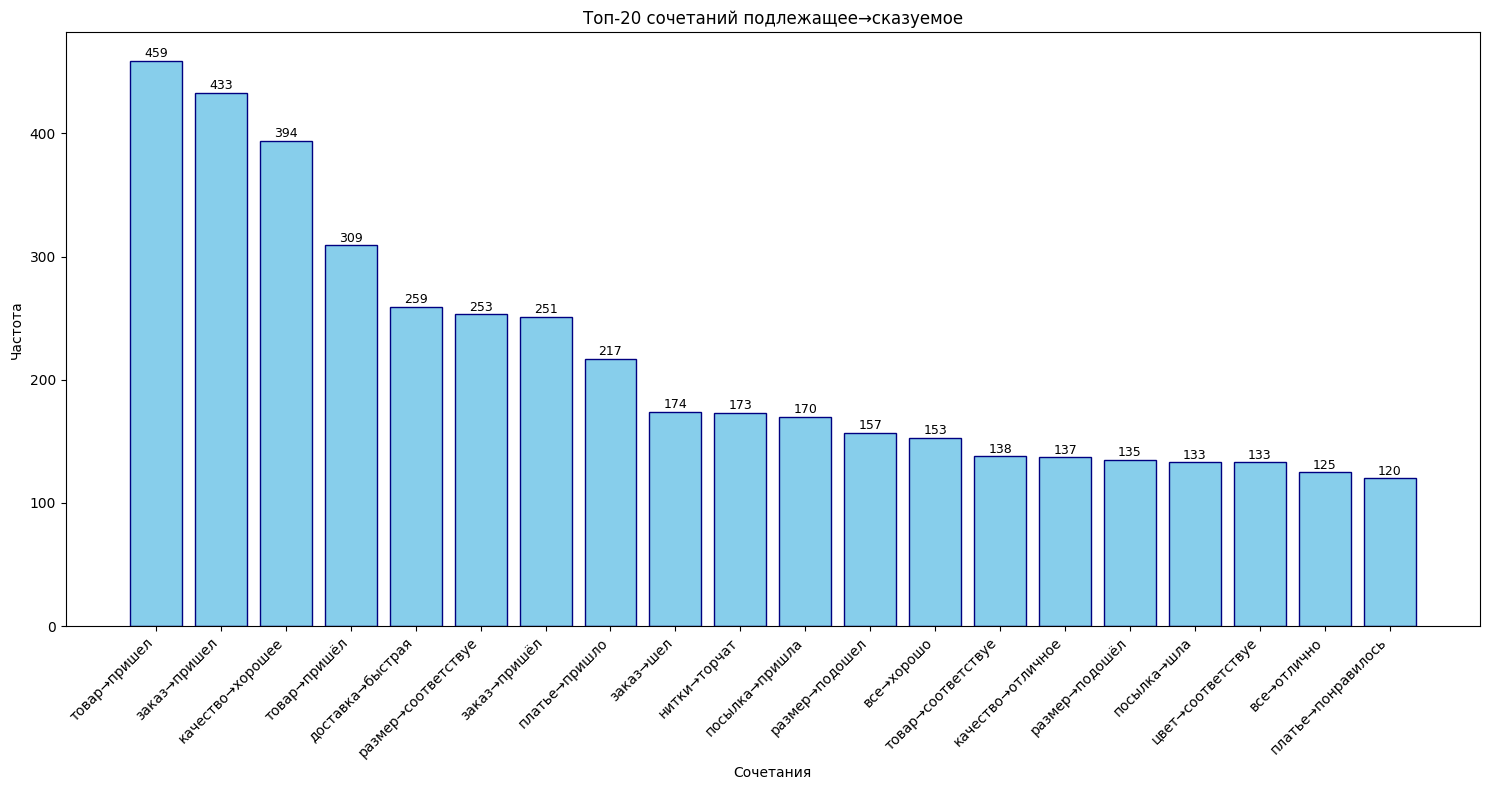

In [10]:
cooccurrences = build_cooccurrence_dependencies(text, segmenter, morph_tagger, 
                                                syntax_parser, morph)
visualize_results(cooccurrences, top_n=20)